In [48]:
# Input Image
# SET PYTHONPATH to the parent directory 
import os
import sys
import torch
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
from einops import rearrange
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from hippy2d.optimal_invariant_cnn import ComplexInvariantConv2D, FILTER_SIZE, MAX_ORDER


import numpy as np
import colorsys

def complex_to_rgb(Z):
    mag = np.abs(Z)
    phase = np.angle(Z)
    norm_mag = mag / mag.max()
    
    hsv = np.zeros(Z.shape + (3,))
    hsv[..., 0] = (phase + np.pi) / (2*np.pi)   # hue
    hsv[..., 1] = 1.0                           # saturation
    hsv[..., 2] = norm_mag                      # value
    
    rgb = np.zeros_like(hsv)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            rgb[i,j] = colorsys.hsv_to_rgb(*hsv[i,j])
    return rgb


In [53]:
layer = ComplexInvariantConv2D(input_size=15, 
                               in_channels=3,
                               out_channels=16,
                               filter_size=FILTER_SIZE,
                               polynomials_magnitude_normalization=False,
                               max_order=MAX_ORDER)

complex_filters = torch.view_as_complex(
    rearrange(layer.filters, '(c m) 1 j k -> m j k c', c=2).contiguous()
)
complex_filters.shape
complex_filters

tensor([[[-0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j,  ...,
           0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j,  ...,
           0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
          -2.9026e-03+2.9026e-03j,  ...,
           2.9026e-03+2.9026e-03j,  0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j],
         ...,
         [-0.0000e+00-0.0000e+00j, -0.0000e+00-0.0000e+00j,
          -2.9026e-03-2.9026e-03j,  ...,
           2.9026e-03-2.9026e-03j,  0.0000e+00-0.0000e+00j,
           0.0000e+00-0.0000e+00j],
         [-0.0000e+00-0.0000e+00j, -0.0000e+00-0.0000e+00j,
          -0.0000e+00-0.0000e+00j,  ...,
           0.0000e+00-0.0000e+00j,  0.0000e+00-0.0000e+00j,
           0.0000e+00-0.0000e+00j],
 

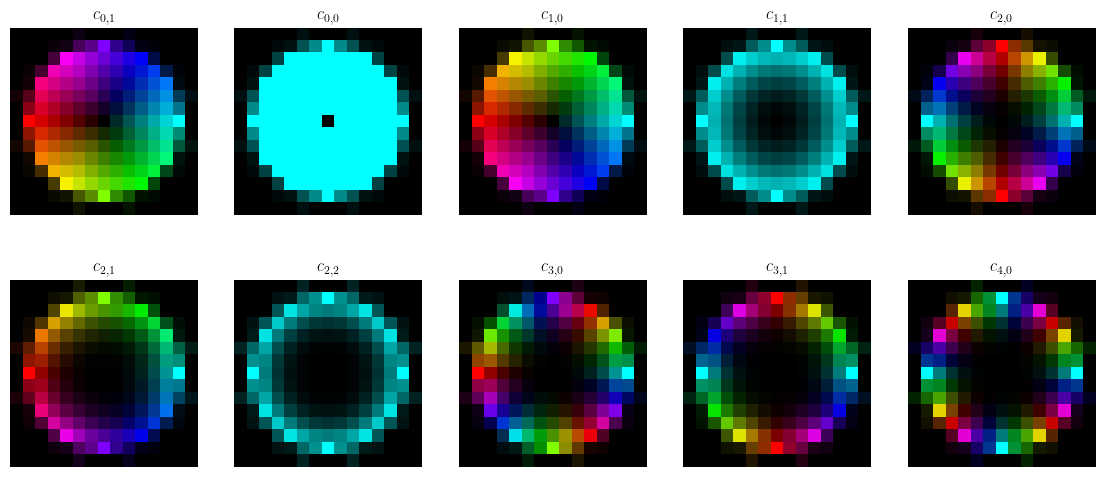

In [54]:
# Plot all the filters
fig, axes = plt.subplots(2, 5, figsize=(14, 6)) 
for i, ax in enumerate(axes.flat):
    if i < complex_filters.shape[0]:
        filter = complex_filters[i].detach()
        #filter = filter / safe_magnitude
        ax.imshow(complex_to_rgb((filter * window).numpy()))
        ax.set_title(f'$c_{{{layer.ind[i][0]},{layer.ind[i][1]}}}$')
    ax.axis('off')